# Review of stats notebook

In [33]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.api import ExponentialSmoothing, Holt, SimpleExpSmoothing



%matplotlib inline

data = [
    446.6565,
    454.4733,
    455.663,
    423.6322,
    456.2713,
    440.5881,
    425.3325,
    485.1494,
    506.0482,
    526.792,
    514.2689,
    494.211,
]

index = pd.date_range(start = "1996", end = "2008", freq = "YE")
oildata = pd.Series(data, index = index)

In [26]:
data = [
    17.5534,
    21.86,
    23.8866,
    26.9293,
    26.8885,
    28.8314,
    30.0751,
    30.9535,
    30.1857,
    31.5797,
    32.5776,
    33.4774,
    39.0216,
    41.3864,
    41.5966,
]

index = pd.date_range(start = "1990", end = "2005", freq = "YE")
airdata = pd.Series(data, index = index)

In [27]:
data = [
    263.9177,
    268.3072,
    260.6626,
    266.6394,
    277.5158,
    283.834,
    290.309,
    292.4742,
    300.8307,
    309.2867,
    318.3311,
    329.3724,
    338.884,
    339.2441,
    328.6006,
    314.2554,
    314.4597,
    321.4138,
    329.7893,
    346.3852,
    352.2979,
    348.3705,
    417.5629,
    417.1236,
    417.7495,
    412.2339,
    411.9468,
    394.6971,
    401.4993,
    408.2705,
    414.2428,
]

index = pd.date_range(start = "1970", end = "2001", freq = "YE")
livestock2 = pd.Series(data, index = index)

data = [407.9979, 403.4608, 413.8249, 428.105, 445.3387, 452.9942, 455.7402]
index = pd.date_range(start = "2001", end = "2008", freq = "YE")
livestock3 = pd.Series(data, index = index)

In [28]:
data = [
    41.7275,
    24.0418,
    32.3281,
    37.3287,
    46.2132,
    29.3463,
    36.4829,
    42.9777,
    48.9015,
    31.1802,
    37.7179,
    40.4202,
    51.2069,
    31.8872,
    40.9783,
    43.7725,
    55.5586,
    33.8509,
    42.0764,
    45.6423,
    59.7668,
    35.1919,
    44.3197,
    47.9137,
]
index = pd.date_range(start="2005", end="2010-Q4", freq = "QS-OCT")
livestock4 = pd.Series(data, index = index)

## Simple Exponential Smoothing

Oil production in saudi arabia from 1996 to 2007.


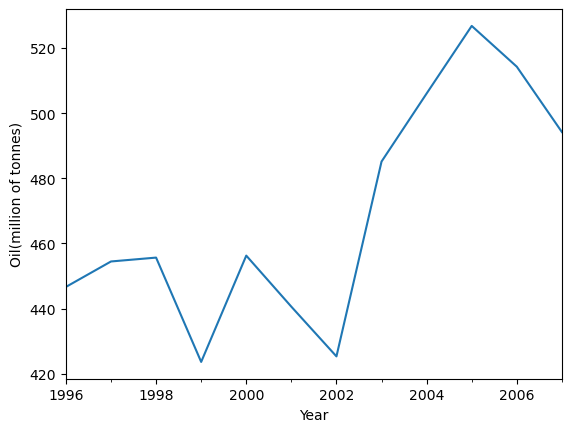

In [11]:
ax = oildata.plot()
ax.set_xlabel('Year')
ax.set_ylabel('Oil(million of tonnes)')
print('Oil production in saudi arabia from 1996 to 2007.')

In [21]:
# variant one for SES, with alpha = 0.2
fit1 = SimpleExpSmoothing(oildata, initialization_method="heuristic").fit(smoothing_level=0.2, optimized=False)
fcast1 = fit1.forecast(steps=3).rename(r"$\alpha=0.2$")

In [18]:
# variant two for SES with alpha = 0.6
fit2 = SimpleExpSmoothing(oildata, initialization_method="heuristic").fit(smoothing_level=0.6, optimized=False)
fcast2 = fit2.forecast(steps=3).rename(r"$\alpha=0.6$")

In [19]:
# variant three for SES with optimized alpha
fit3 = SimpleExpSmoothing(oildata, initialization_method="estimated").fit()
fcast3 = fit3.forecast(steps=3).rename(r"$\alpha=0.3$" % fit3.model.params["smoothing_level"])

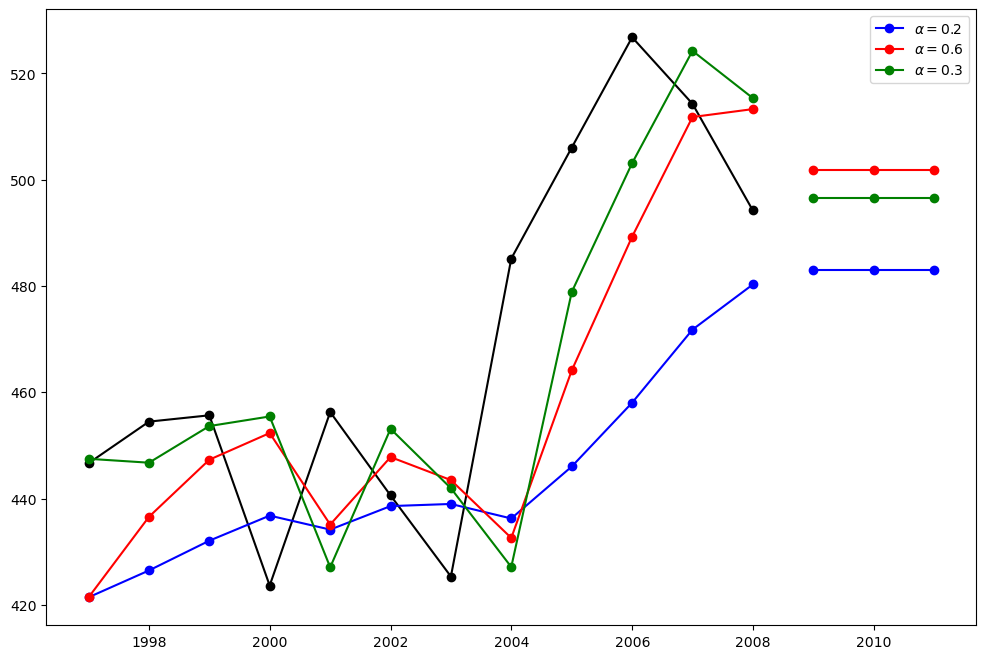

In [24]:
# plotting the three variants of SES
plt.figure(figsize = (12,8))
plt.plot(oildata, marker = "o", color="black")
plt.plot(fit1.fittedvalues, marker = "o", color="blue")
(line1,)= plt.plot(fcast1, marker = "o", color="blue")
plt.plot(fit2.fittedvalues, marker="o", color="red")
(line2,) = plt.plot(fcast2, marker="o", color="red")
plt.plot(fit3.fittedvalues, marker="o", color="green")
(line3,) = plt.plot(fcast3, marker="o", color="green")
plt.legend([line1, line2, line3], [fcast1.name, fcast2.name, fcast3.name])

## Holt's Method

In [29]:
# variant one: with alpha = 0.8 and beta = 0.2
fit1 = Holt(airdata, initialization_method="estimated").fit(smoothing_level=0.8, smoothing_trend=0.8, optimized=False )
fcast1 = fit1.forecast(steps=5).rename("Holt's linear Trend")

In [30]:
# variant two: same as variant one but exponential trend
fit2 = Holt(airdata, exponential=True, initialization_method="estimated").fit(smoothing_level=0.8, smoothing_trend=0.8, optimized=False)
fcast2 = fit2.forecast(steps=5).rename("Holt's exponential Trend")

In [31]:
# variant three: Holt's linear trend with additive and damped effect
fit3 = Holt(airdata, damped_trend=True, initialization_method="estimated").fit(smoothing_level=0.8, smoothing_trend=0.8)
fcast3 = fit3.forecast(steps=5).rename("Holt's additive damped trend")

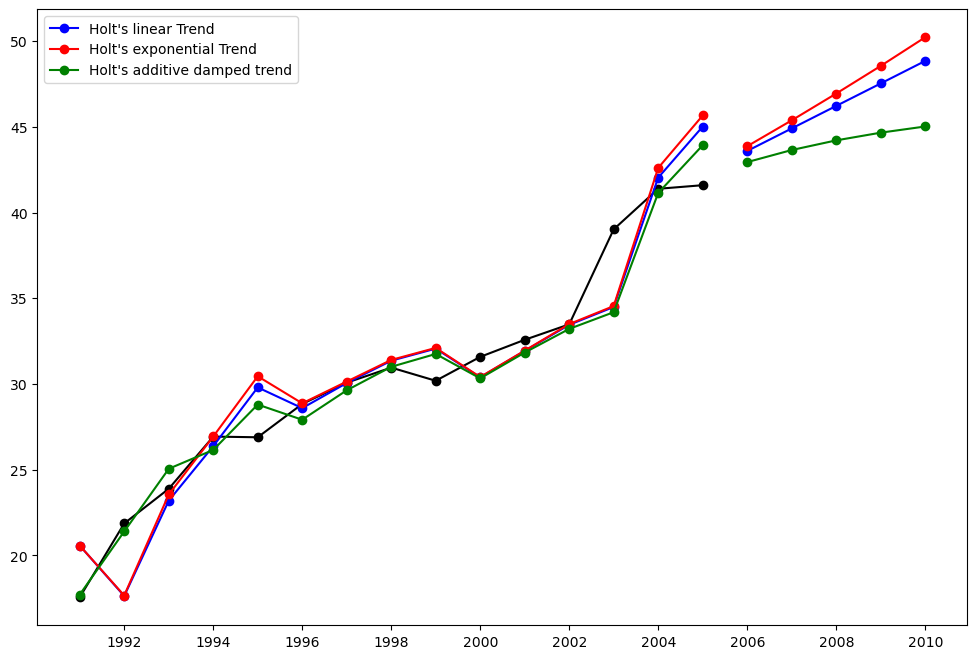

In [32]:
# plotting
plt.figure(figsize = (12,8))
plt.plot(airdata, marker = "o", color="black")
plt.plot(fit1.fittedvalues, marker = "o", color="blue")
(line1,) = plt.plot(fcast1, marker = "o", color="blue")
plt.plot(fit2.fittedvalues, marker = "o", color="red")
(line2,) = plt.plot(fcast2, marker = "o", color="red")
plt.plot(fit3.fittedvalues, marker = "o", color="green")
(line3,) = plt.plot(fcast3, marker = "o", color="green")
plt.legend([line1, line2, line3], [fcast1.name, fcast2.name, fcast3.name])

## Seasonally adjusted on livestock data

In [35]:
fit1 = SimpleExpSmoothing(livestock2, initialization_method="estimated").fit()
fit2 = Holt(livestock2, initialization_method="estimated").fit()
fit3 = Holt(livestock2, exponential=True ,initialization_method="estimated").fit()
fit4 = Holt(livestock3, damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(livestock2, exponential=True, damped_trend=True ,initialization_method="estimated").fit()

params = [
    "smoothing_level",
    "smoothing_trend",
    "damping_trend",
    "initial_level",
    "initial_trend",
]

results = pd.DataFrame(index=[r"$\alpha$", r"$\beta$", r"$\phi$", r"$l_0$", "$b_0$", "SSE"],
                       columns = ["SES", "Holt's", "Exponential", "Additive", "Multiplicative"],)
results["SES"] = [fit1.params[p] for p  in params] + [fit1.sse]
results["Holt's"] = [fit2.params[p] for p  in params] + [fit2.sse]
results["Exponential"] = [fit3.params[p] for p  in params] + [fit3.sse]
results["Additive"] = [fit4.params[p] for p  in params] + [fit4.sse]
results["Multiplicative"] = [fit5.params[p] for p  in params] + [fit5.sse]
results

,SES,Holt's,Exponential,Additive,Multiplicative
$\alpha$,1.000000,0.974306,9.776735e-01,1.000000,9.749160e-01
$\beta$,NaN,0.000000,1.354763e-09,1.000000,2.002597e-12
$\phi$,NaN,NaN,NaN,0.980000,9.816476e-01
$l_0$,263.917696,258.880313,2.603423e+02,412.627600,2.589518e+02
$b_0$,NaN,5.010856,1.013780e+00,-4.724150,1.038142e+00
SSE,6761.350235,6004.138205,6.104195e+03,354.724806,6.081995e+03


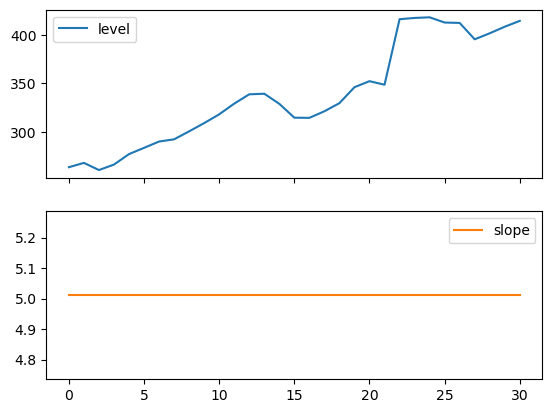

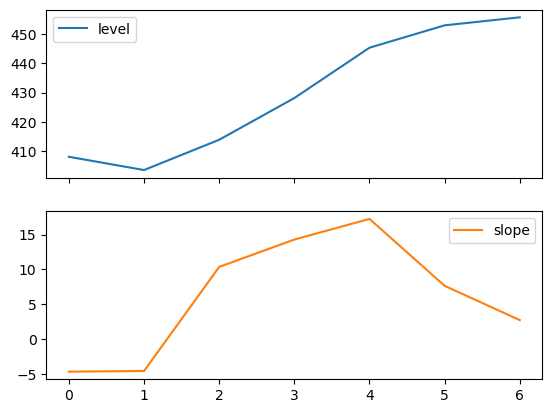

Level and slope components for Holt’s linear trend method and the additive damped trend method.


In [36]:
# plotting
for fit in [fit2, fit4]:
    pd.DataFrame(np.c_[fit.level, fit.trend]).rename(
        columns={0: "level", 1: "slope"}
    ).plot(subplots=True)
plt.show()
print(
    "Level and slope components for Holt’s linear trend method and the additive damped trend method."
)


# Synthetic signals

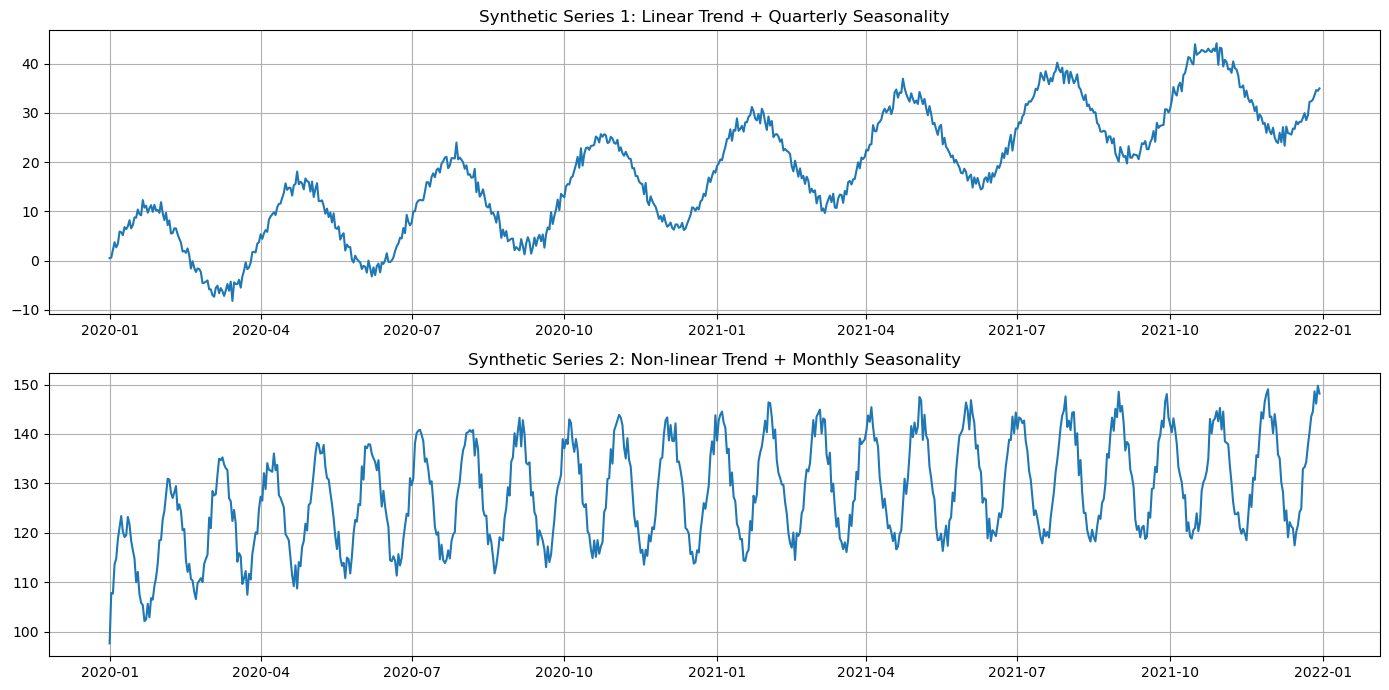

In [3]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import ExponentialSmoothing
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic time series data with known components
n = 365 * 2
t = np.arange(n)

# Series 1: Linear trend + Single seasonality + Noise
trend1 = 0.05 * t
seasonality1 = 10 * np.sin(2 * np.pi * t / (365 / 4))  # Quartertly seasonality
noise1 = np.random.normal(0, 1, n)
# Combined series
series1 = trend1 + seasonality1 + noise1
series1_components = {'trend': trend1, 'seasonal': seasonality1, 'residual': noise1}

# Series 2: Non-linear trend + Multiple seasonality + Noise

trend2 = 100 + 5 * np.log(1+t)
seasonality2 = 1 + 0.1 * np.sin(2 * np.pi * t / 30)
noise2 = 1 + 0.05 * (np.random.random(n) - 0.5)

# MULTIPLICATIVE model: trend × seasonality × noise
series2 = trend2 * seasonality2 * noise2

# Create DataFrames for the time series
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')
synthetic_df = pd.DataFrame({
    'date': dates,
    'series1': series1,
    'series2': series2,
})
synthetic_df.set_index('date', inplace=True)

# Plot the synthetic time series
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(dates, series1)
plt.title('Synthetic Series 1: Linear Trend + Quarterly Seasonality')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(dates, series2)
plt.title('Synthetic Series 2: Non-linear Trend + Monthly Seasonality')
plt.grid(True)

plt.tight_layout()
plt.show()


## Comparing variations of ETS error, trend, seasonality
### (1)
- for synthetic_df1: ETS(A,N,N)
- for synthetic_df2: ETS(A,N,N)

In [4]:
from utils import plot_ets

synthetic_df1 = synthetic_df['series1']
synthetic_df2 = synthetic_df['series2']

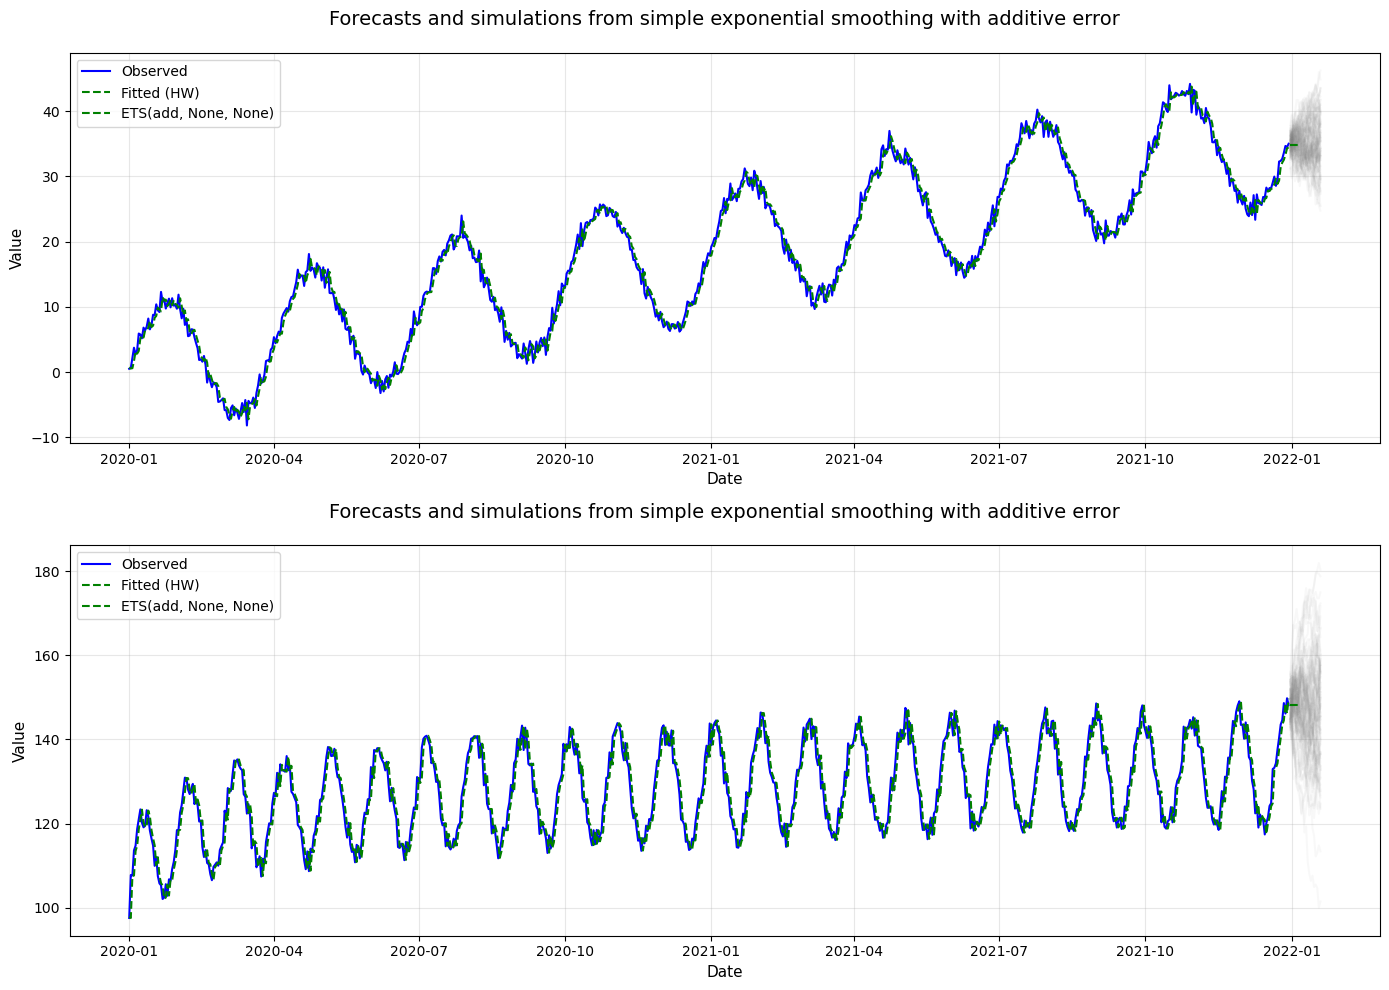

In [5]:
# simple exponential smoothing with additive error process
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend=None, seasonal= None, title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20)

### (2)
- for synthetic_df1: ETS(A,A,N)
- for synthetic_df2: ETS(A,A,N)

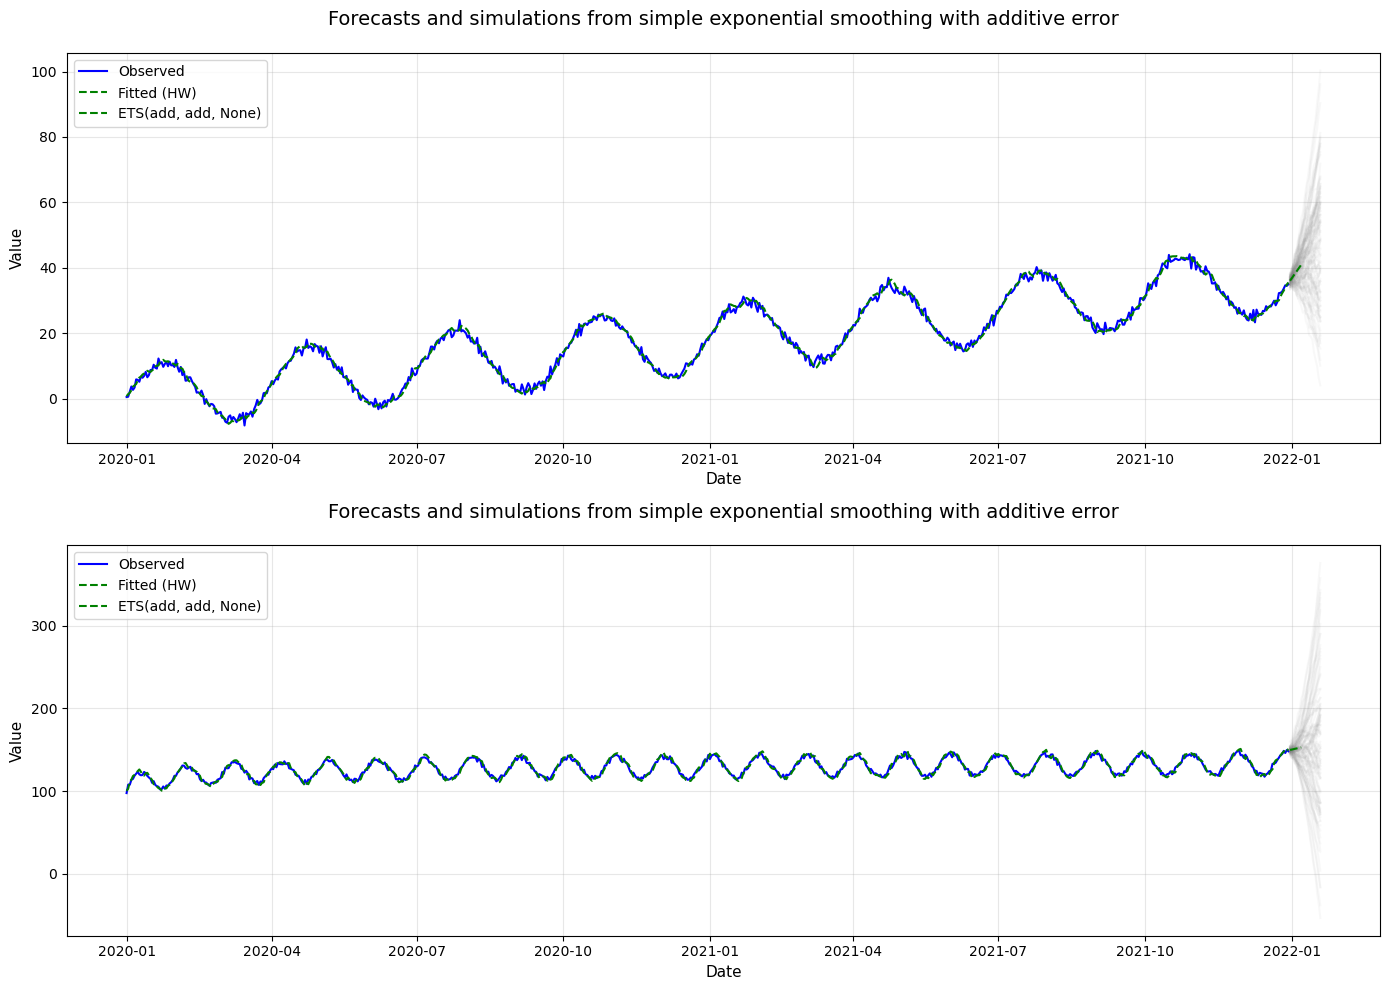

In [7]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", seasonal= None, title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20)

### (3)
- for synthetic_df1: ETS(A,A,A)
- for synthetic_df2: ETS(A,A,A)

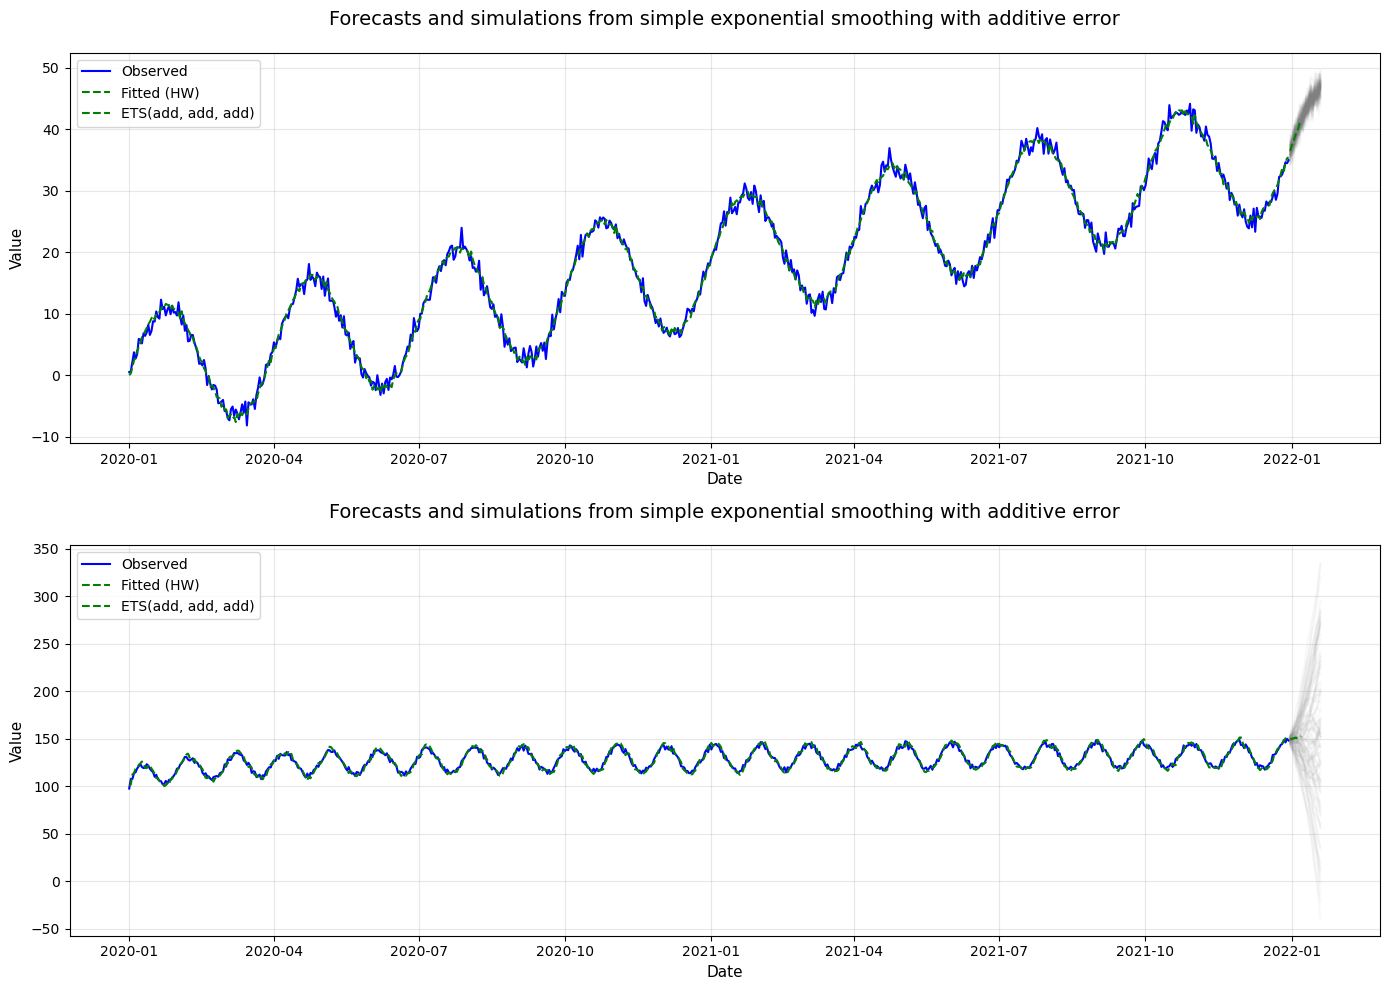

In [8]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", seasonal= "add", title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20)

### (3)
- for synthetic_df1: ETS(A,A,M)
- for synthetic_df2: ETS(A,A,M)

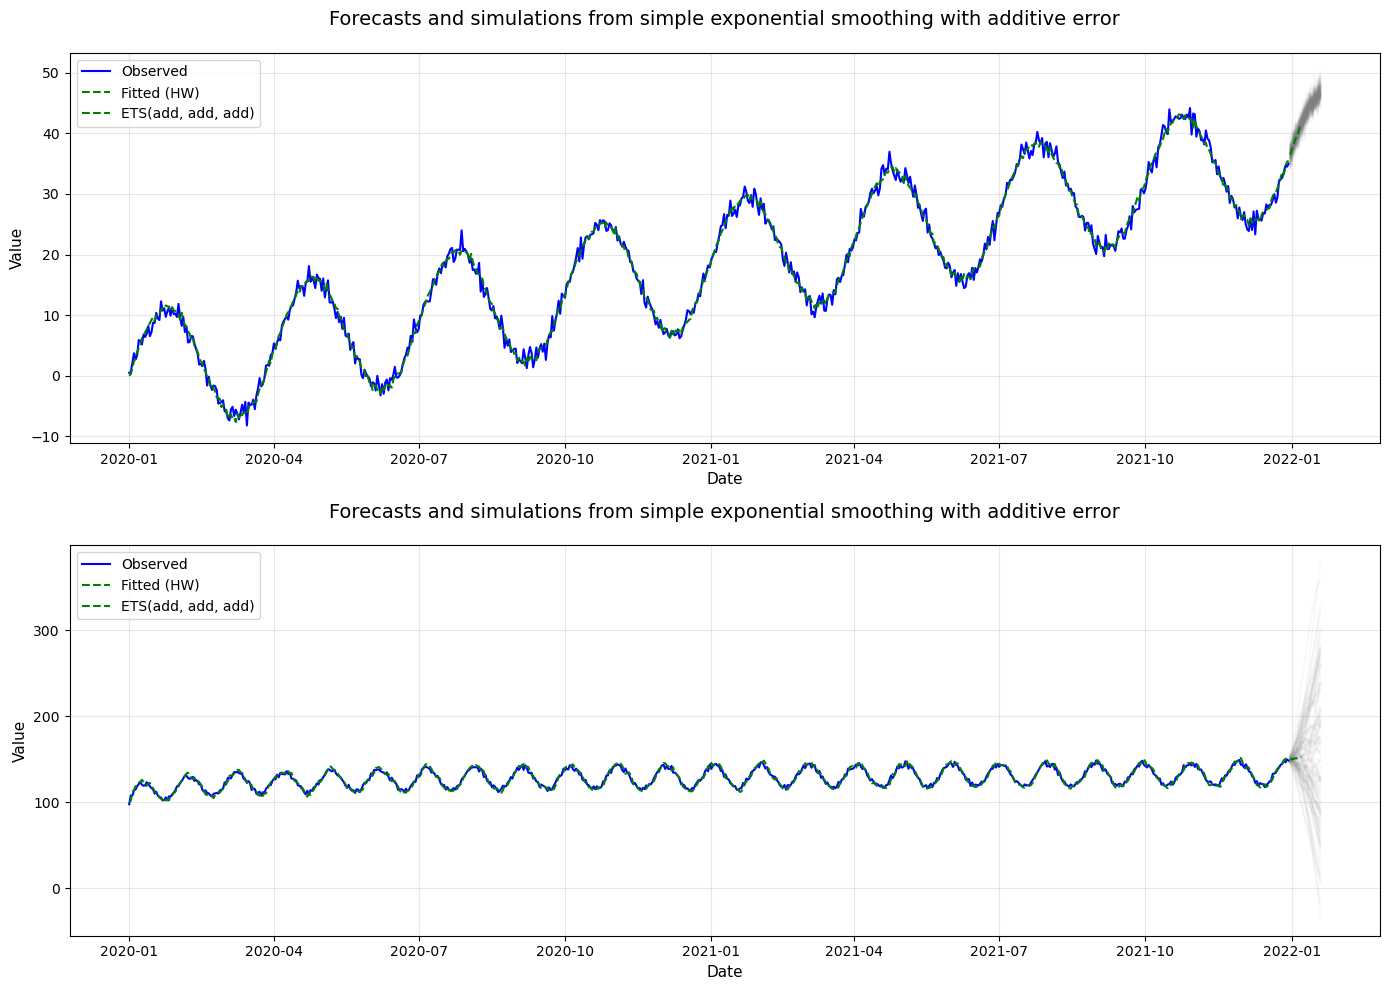

In [9]:
plot_ets(synthetic_df1, synthetic_df2, period=[int(365/4), int(730/30)],trend="add", seasonal= "add", title='Forecasts and simulations from simple exponential smoothing with additive error', nsimulations=20)

### Analysis

#### plotting using plotly

In [97]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

synthetic_df1 = synthetic_df['series1']
synthetic_df2 = synthetic_df['series2']

# simple exponential smoothing with error process
fit1 = ExponentialSmoothing(synthetic_df1, seasonal_periods=int(365/4), trend="add", seasonal="add", initialization_method="estimated", freq='D').fit()
simulations1 = fit1.simulate(8, repetitions=100, error="add")

fit2 = ExponentialSmoothing(synthetic_df2, seasonal_periods=int(730/30), trend="add", seasonal="mul", initialization_method="estimated", freq='D').fit()
simulations2 = fit2.simulate(8, repetitions=100, error="add")

# Create subplots
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Forecasts and simulations from Additive Holt–Winters method with additive error',
                    'Forecasts and simulations from Additive Holt–Winters method with multiplicative seasonality'),
    vertical_spacing=0.12
)

# Plot 1: Series 1
# Simulations (plot first so they're in background)
for col in simulations1.columns:
    fig.add_trace(
        go.Scatter(x=simulations1.index, y=simulations1[col],
                   mode='lines',
                   line=dict(color='grey', width=0.5),
                   opacity=0.15,
                   showlegend=False,
                   hoverinfo='skip'),
        row=1, col=1
    )

# Observed data
fig.add_trace(
    go.Scatter(x=synthetic_df1.index, y=synthetic_df1,
               mode='lines',
               name='Observed',
               line=dict(color='#00D9FF', width=2)),
    row=1, col=1
)

# Fitted values
fig.add_trace(
    go.Scatter(x=fit1.fittedvalues.index, y=fit1.fittedvalues,
               mode='lines',
               name='Fitted (HW)',
               line=dict(color='#00FF88', width=2, dash='dash')),
    row=1, col=1
)

# Forecast
forecast1 = fit1.forecast(8)
fig.add_trace(
    go.Scatter(x=forecast1.index, y=forecast1,
               mode='lines+markers',
               name='Holt-Winters (add-add-seasonal)',
               line=dict(color='#FF6B6B', width=2, dash='dash'),
               marker=dict(size=6)),
    row=1, col=1
)

# Plot 2: Series 2
# Simulations (plot first so they're in background)
for col in simulations2.columns:
    fig.add_trace(
        go.Scatter(x=simulations2.index, y=simulations2[col],
                   mode='lines',
                   line=dict(color='grey', width=0.5),
                   opacity=0.15,
                   showlegend=False,
                   hoverinfo='skip'),
        row=2, col=1
    )

# Observed data
fig.add_trace(
    go.Scatter(x=synthetic_df2.index, y=synthetic_df2,
               mode='lines',
               name='Observed',
               line=dict(color='#00D9FF', width=2),
               showlegend=False),
    row=2, col=1
)

# Fitted values
fig.add_trace(
    go.Scatter(x=fit2.fittedvalues.index, y=fit2.fittedvalues,
               mode='lines',
               name='Fitted (HW)',
               line=dict(color='#00FF88', width=2, dash='dash'),
               showlegend=False),
    row=2, col=1
)

# Forecast
forecast2 = fit2.forecast(8)
fig.add_trace(
    go.Scatter(x=forecast2.index, y=forecast2,
               mode='lines+markers',
               name='Holt-Winters (add-mul-seasonal)',
               line=dict(color='#FF6B6B', width=2, dash='dash'),
               marker=dict(size=6),
               showlegend=False),
    row=2, col=1
)

# Update layout with dark theme
fig.update_xaxes(title_text="Date", row=1, col=1, gridcolor='#333333', showgrid=True)
fig.update_xaxes(title_text="Date", row=2, col=1, gridcolor='#333333', showgrid=True)
fig.update_yaxes(title_text="Value", row=1, col=1, gridcolor='#333333', showgrid=True)
fig.update_yaxes(title_text="Value", row=2, col=1, gridcolor='#333333', showgrid=True)

fig.update_layout(
    height=800,
    showlegend=True,
    hovermode='x unified',
    template='plotly_dark',
    paper_bgcolor='#000000',
    plot_bgcolor='#000000',
    font=dict(color='#FFFFFF'),
    title_font=dict(color='#FFFFFF')
)

# Update subplot titles color
for annotation in fig.layout.annotations:
    annotation.font.color = '#FFFFFF'

fig.show()